# Content Intelligence: Unstructured Caption Analysis
this analyzes unstructured social media caption data
The goal is to extract themes, clean text, and identify commonly used hashtags.

Steps performed:
- Load raw text data
- Extract hashtags using regex
- Clean text (remove punctuation + hashtags)
- Analyze word frequency
- Visualize top hashtags
- Save processed structured dataset

In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt

# Load captions
with open("data/raw/captions_raw.txt", "r", encoding="utf-8") as f:
    captions = [line.strip() for line in f.readlines() if line.strip()]

print("Number of captions:", len(captions))

# Extract hashtags
hashtags = []
for cap in captions:
    hashtags += re.findall(r"#\w+", cap.lower())

# Clean text (remove hashtags + punctuation)
def clean_text(text):
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text.lower().strip()

cleaned = [clean_text(c) for c in captions]

# Most common words
words = " ".join(cleaned).split()
common_words = Counter(words).most_common(15)

# Most common hashtags
common_hashtags = Counter(hashtags).most_common(10)

print("\nTop Words:")
print(common_words)

print("\nTop Hashtags:")
print(common_hashtags)

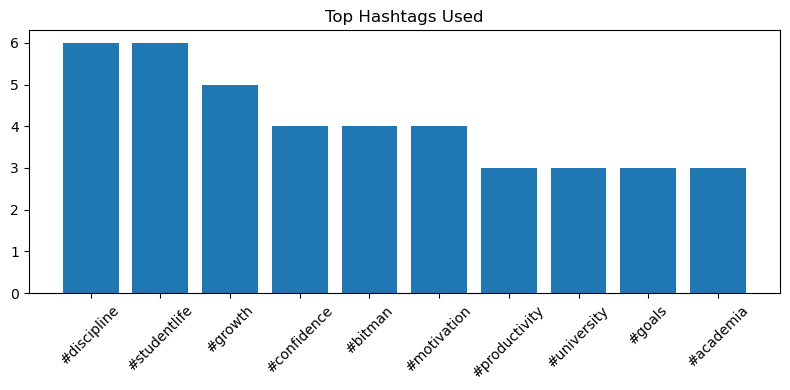

In [5]:
# Create bar chart of top 10 hashtags

top_hashtags = common_hashtags[:10]
labels = [h[0] for h in top_hashtags]
values = [h[1] for h in top_hashtags]

plt.figure(figsize=(8,4))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Top Hashtags Used")
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

# Create dataframe
df = pd.DataFrame({
    "original_caption": captions,
    "cleaned_caption": cleaned
})

# Save processed version
df.to_csv("data/processed/captions_cleaned.csv", index=False)

df.head()

,original_caption,cleaned_caption
0,Morning skincare + iced coffee kind of day ✨💖 ...,morning skincare iced coffee kind of day
1,Pink gym set hits different 💕💪 #fitnessgirl #d...,pink gym set hits different
2,Studying but make it aesthetic 📚✨ #studentlife...,studying but make it aesthetic
3,Manifesting good grades and good vibes only 🌸 ...,manifesting good grades and good vibes only
4,That post-presentation glow is real 💅✨ #confid...,that postpresentation glow is real
